# 02. 서브그래프(Subgraphs)

> 큰 그래프는 작은 그래프를 합쳐 만들어요. **공유 키 / 독립 스키마** 두 가지 서브그래프 패턴과 3계층 중첩까지 다루며 모듈화 전략을 익혀요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **공유 키(Shared Keys) 패턴**으로 컴파일된 서브그래프를 부모 그래프의 노드로 직접 추가할 수 있어요
2. **독립 스키마(Independent Schemas) 패턴**으로 래퍼(wrapper) 함수를 작성해 두 그래프의 상태를 변환할 수 있어요
3. **3계층 서브그래프 구조**(grandchild → child → parent)를 설계하고 구현할 수 있어요
4. `subgraphs=True` 옵션으로 중첩된 서브그래프의 내부 실행 흐름을 스트리밍으로 확인할 수 있어요

## 사전 지식

- `StateGraph`, `TypedDict`, `add_node`, `add_edge` 기본 사용법 (Part 2 참고)
- 이전 노트북 `01-Functional-API.ipynb`에서 배운 `@entrypoint`, `@task` 함수형 API

## 서브그래프란?

서브그래프(Subgraph)는 **그래프 안에 또 다른 그래프를 포함**하는 구조예요. 복잡한 워크플로우를 독립적인 모듈로 나누거나, 멀티 에이전트 시스템에서 각 에이전트를 별도의 그래프로 구성할 때 매우 유용해요.

### 왜 서브그래프를 사용하나요?

레고 블록을 상상해보세요. 작은 블록들을 조합해서 큰 구조물을 만들 듯, 작은 그래프를 조합해서 복잡한 시스템을 만들어요. 각 서브그래프는 **독립적으로 개발/테스트/재사용**할 수 있어서 코드 관리가 훨씬 쉬워져요.

서브그래프를 추가하는 방법은 **두 그래프가 상태(State)를 어떻게 공유하느냐**에 따라 달라져요:

| 패턴 | 상태 관계 | 구현 방법 | 비유 |
|------|----------|----------|------|
| **Case 1: 공유 키** | 부모-자식이 동일한 키를 가짐 | 컴파일된 서브그래프를 `add_node`에 직접 전달 | 같은 언어를 쓰는 팀 (직접 대화) |
| **Case 2: 독립 스키마** | 부모-자식이 완전히 다른 키 사용 | 래퍼 함수를 노드로 등록하고 그 안에서 `invoke()` 호출 | 다른 언어를 쓰는 팀 (통역사 필요) |

> 🔑 **핵심 개념**: 서브그래프에서 **공유되지 않는 키**는 부모 그래프로 전파되지 않아요. 이를 **프라이빗 상태(Private State)**라고 해요. 자식 그래프 내부에서만 쓰이는 임시 키를 분리할 수 있어서 각 레이어의 독립성을 보장해요.

### 잠깐: 서브그래프와 서브에이전트는 무엇이 다를까요?

두 용어가 비슷하게 들리지만, 기준점이 달라요.

| 구분 | 서브그래프(Subgraph) | 서브에이전트(Subagent) |
|------|----------------------|-------------------------|
| 핵심 관점 | **그래프 구조**를 나누고 합치는 구현 단위 | **작업 역할**을 나누어 위임하는 에이전트 패턴 |
| 대표 형태 | `StateGraph`를 컴파일한 그래프를 부모 그래프의 노드로 사용 | 감독자(supervisor) 에이전트가 전문 에이전트를 도구처럼 호출 |
| 상태 공유 | 공유 키/프라이빗 키처럼 **State 채널** 기준으로 연결 | 보통 별도 메시지/컨텍스트 창에서 실행하고 결과만 감독자에게 반환 |
| 디버깅 관점 | 정적으로 연결된 경우 `subgraphs=True`로 내부 실행 흐름 추적 가능 | 도구 함수 안에서 호출하면 중첩 State가 자동으로 보이지 않을 수 있음 |
| 관계 | 서브에이전트를 구현하는 한 방법이 될 수 있음 | 내부 구현이 LangGraph 서브그래프일 수도 있고 아닐 수도 있음 |

> 한 문장으로 정리하면, **서브그래프는 그래프를 모듈화하는 방법**이고, **서브에이전트는 일을 전문 역할에게 위임하는 설계 패턴**이에요. 예를 들어 “배송 전문 에이전트”는 서브에이전트이고, 그 에이전트의 내부 절차가 `StateGraph`로 만들어져 부모 그래프에 연결되면 서브그래프이기도 합니다.


### 전체 아키텍처

```mermaid
flowchart TD
    subgraph PARENT["부모 그래프 (ParentState)"]
        P1["node_1"] --> C1
        subgraph SUBGRAPH_NODE["서브그래프 노드"]
            C1["subgraph_node_1"] --> C2["subgraph_node_2"]
        end
        C2 --> PE["END"]
    end

    A["입력"] --> P1
    PE --> B["출력"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class A input
    class P1,C1,C2 process
    class PE,B output
    style SUBGRAPH_NODE fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🎯 **강의 포인트**: 두 패턴을 직접 비교해볼게요. **Case 1**은 공유 키 덕분에 서브그래프를 그대로 연결할 수 있고, **Case 2**는 래퍼 함수가 상태 변환의 다리 역할을 해요.

## 0. 환경 설정

In [1]:
# 환경 변수를 .env 파일에서 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LangSmith 추적 설정 - 그래프 실행 흐름을 온라인에서 확인할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Subgraphs"

## 1. Case 1: 공유 키(Shared Keys) 패턴

부모 그래프와 서브그래프가 **동일한 상태 키를 공유**하는 가장 일반적인 패턴이에요. 예를 들어 멀티 에이전트 시스템에서 모든 에이전트가 `messages` 키를 공유하는 경우가 대표적이에요.

### 구현 단계

1. 서브그래프 상태(`ChildState`)와 노드 함수를 정의한 뒤 컴파일해요
2. 부모 그래프에서 `builder.add_node("node_2", subgraph)`처럼 **컴파일된 서브그래프 객체를 직접 전달**해요

> 🔑 **핵심 개념**: `ChildState`에는 부모와 **공유하는 키**(name)와 **서브그래프 전용 키**(family_name)가 함께 있어요. LangGraph는 공유 키만 부모 ↔ 자식 사이에서 자동으로 전달하고, 전용 키는 서브그래프 내부에만 머물러요.

### 공유 키는 어떻게 결정되나요?

LangGraph에서 부모 그래프와 서브그래프를 `builder.add_node("node_2", subgraph)`처럼 **직접 연결**할 때, 공용 채널은 State 클래스 이름이 아니라 **상태 딕셔너리의 키 이름**으로 결정돼요.

- `ParentState.name`과 `ChildState.name`처럼 **키 이름이 같으면** 같은 state channel로 취급돼요.
- `ChildState.family_name`처럼 부모 State에 없는 키는 **서브그래프 내부 전용 키**예요.
- 두 State 전체가 같을 필요는 없어요. **공유할 키만 일치**하면 되고, 자식은 내부 처리용 키를 추가로 가질 수 있어요.
- 키 이름이 다르면 자동 공유가 아니므로, Case 2처럼 래퍼 함수에서 `부모 상태 → 자식 입력 → 부모 출력`을 직접 매핑해야 해요.
- 같은 이름의 키는 서로 값을 주고받는 통로이므로, 타입과 reducer 의미도 맞춰 두는 것이 안전해요.


In [3]:
# LangGraph의 핵심 그래프 구성 요소를 가져와요
from langgraph.graph import START, END, StateGraph
from typing import TypedDict


# 서브그래프 상태 정의
# - name: 부모 그래프(ParentState)와 공유되는 키
# - family_name: 서브그래프 내부에서만 사용하는 프라이빗 키
class ChildState(TypedDict):
    name: str         # 공유 키: 부모와 서브그래프 모두 접근 가능
    family_name: str  # 프라이빗 키: 서브그래프 내부에서만 사용

In [4]:
# ---------------------------------------------------
# 서브그래프 노드 함수 정의
# ---------------------------------------------------

def subgraph_node_1(state: ChildState):
    """서브그래프 첫 번째 노드

    프라이빗 키 family_name에 성(姓)을 설정해요.
    이 값은 부모 그래프로 전파되지 않아요.
    """
    # family_name은 서브그래프 전용 키 - 부모에게 전달되지 않아요
    return {"family_name": "Lee"}


def subgraph_node_2(state: ChildState):
    """서브그래프 두 번째 노드

    공유 키 name과 프라이빗 키 family_name을 합쳐 full name을 만들어요.
    변경된 name은 공유 키이므로 부모 그래프에 전달돼요.
    """
    # 공유 키(name) + 프라이빗 키(family_name) → 새로운 name 생성
    return {"name": f'{state["name"]} {state["family_name"]}'}


# 서브그래프 빌더를 만들고 노드와 엣지를 연결해요
subgraph_builder = StateGraph(ChildState)
subgraph_builder.add_node(subgraph_node_1)   # 노드 이름: 함수명(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)   # 노드 이름: 함수명(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")

# 서브그래프를 컴파일해요 - 이 객체를 부모 그래프 노드로 직접 추가할 수 있어요
subgraph = subgraph_builder.compile()

# 서브그래프 컴파일 완료!

### 서브그래프 시각화

`xray=True` 옵션을 사용하면 내부 노드 구조까지 상세하게 볼 수 있어요.

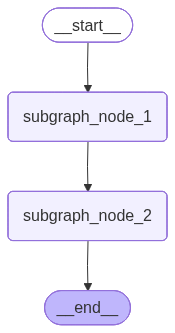

In [5]:
# 그래프 흐름: START → subgraph_node_1 → subgraph_node_2 → END
# subgraph_node_1: 프라이빗 키 family_name에 성(姓)을 설정해요
# subgraph_node_2: 공유 키 name과 프라이빗 키 family_name을 합쳐 full name을 만들어요
from IPython.display import Image, display

# xray=True: 서브그래프 내부 구조도 함께 펼쳐서 보여줘요
display(Image(subgraph.get_graph(xray=True).draw_mermaid_png()))

### 부모 그래프 정의

이제 서브그래프를 포함하는 부모 그래프를 만들어요. 핵심은 `builder.add_node("node_2", subgraph)`처럼 **컴파일된 서브그래프 객체를 직접 전달**하는 거예요.

> 💡 **실무 팁**: 공유 키 패턴은 멀티 에이전트에서 모든 에이전트가 `messages` 리스트를 공유할 때 특히 유용해요. 각 에이전트 그래프를 독립적으로 개발하고, 공유 키만 맞춰두면 바로 연결할 수 있어요.

In [6]:
# 부모 그래프 상태 정의: 서브그래프(ChildState)와 name 키를 공유해요
class ParentState(TypedDict):
    name: str  # 서브그래프와 공유되는 키


def node_1(state: ParentState):
    """부모 그래프 첫 번째 노드

    입력받은 name 앞에 'My name is'를 붙여요.
    이 값이 공유 키를 통해 서브그래프로 전달돼요.
    """
    return {"name": f'My name is {state["name"]}'}


# 부모 그래프 빌더 설정
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)

# 핵심: 컴파일된 서브그래프를 노드로 직접 추가해요
# LangGraph가 공유 키(name)를 통해 상태를 자동으로 전달해요
builder.add_node("node_2", subgraph)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 부모 그래프 컴파일
graph = builder.compile()

# 부모 그래프 컴파일 완료!

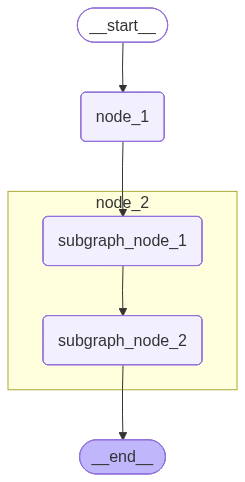

In [7]:
# 그래프 흐름: START → node_1 → node_2(서브그래프) → END
# node_1: 입력 name 앞에 'My name is'를 붙여요
# node_2(서브그래프): subgraph_node_1 → subgraph_node_2 순으로 실행하며 성(姓)을 합쳐요
# 공유 키(name)만 부모-자식 간 자동 전달돼요
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

### 그래프 실행 — 기본 스트리밍

기본 스트리밍에서는 **상위 그래프 노드의 출력만** 보여줘요. 서브그래프 내부의 중간 단계는 표시되지 않아요.

In [8]:
# ---------------------------------------------------
# 기본 스트리밍: 부모 그래프 노드 출력만 표시
# ---------------------------------------------------
# === 기본 스트리밍 (부모 노드만 표시) ===
for chunk in graph.stream({"name": "Alex"}):
    print(chunk)

{'node_1': {'name': 'My name is Alex'}}
{'node_2': {'name': 'My name is Alex Lee'}}


### 그래프 실행 — subgraphs=True 옵션

`subgraphs=True`를 추가하면 서브그래프 내부의 중간 단계까지 모두 볼 수 있어요. 출력 형식이 `(네임스페이스 튜플, 상태 딕셔너리)` 형태로 변경돼요.

- 빈 튜플 `()` = 부모(상위) 그래프에서 발생한 이벤트
- `('node_2:...',)` = 서브그래프 내부에서 발생한 이벤트

> 🎯 **강의 포인트**: 네임스페이스 튜플을 보면 어떤 서브그래프에서 이벤트가 왔는지 바로 알 수 있어요. 복잡한 멀티 에이전트 디버깅 시 어떤 에이전트가 어떤 출력을 냈는지 추적하는 데 핵심적인 기능이에요.

In [9]:
# ---------------------------------------------------
# subgraphs=True: 서브그래프 내부 단계까지 모두 표시
# ---------------------------------------------------
# === subgraphs=True (내부 단계까지 표시) ===
for namespace, chunk in graph.stream({"name": "Alex"}, subgraphs=True):
    # namespace: 이벤트가 발생한 그래프 계층 정보
    # chunk: 해당 노드의 출력 상태
    if namespace:  # 빈 튜플이 아니면 서브그래프 이벤트
        print(f"  [서브그래프] {namespace}: {chunk}")
    else:          # 빈 튜플이면 부모 그래프 이벤트
        print(f"[부모 그래프] {chunk}")

[부모 그래프] {'node_1': {'name': 'My name is Alex'}}
  [서브그래프] ('node_2:f934eba8-88e3-d46c-e342-7c3a475be129',): {'subgraph_node_1': {'family_name': 'Lee'}}
  [서브그래프] ('node_2:f934eba8-88e3-d46c-e342-7c3a475be129',): {'subgraph_node_2': {'name': 'My name is Alex Lee'}}
[부모 그래프] {'node_2': {'name': 'My name is Alex Lee'}}


## 2. Case 2: 독립 스키마(Independent Schemas) 패턴

부모 그래프와 서브그래프의 상태 키가 **완전히 다른 경우**예요. 이때는 컴파일된 서브그래프를 직접 노드로 추가할 수 없어요.

대신 **래퍼(wrapper) 함수**를 노드로 등록하고, 그 안에서 두 가지 변환을 수행해요:

1. **호출 전**: 부모 상태 -> 서브그래프 입력 형식으로 변환
2. **호출 후**: 서브그래프 출력 -> 부모 상태 형식으로 변환

### Case 1 vs Case 2 비교

| 비교 항목 | Case 1: 공유 키 | Case 2: 독립 스키마 |
|-----------|----------------|---------------------|
| 구현 난이도 | 쉬움 (직접 전달) | 중간 (래퍼 함수 필요) |
| 상태 변환 | 자동 (LangGraph가 처리) | 수동 (개발자가 구현) |
| 재사용성 | 공유 키가 일치해야 함 | 어떤 서브그래프든 연결 가능 |
| 사용 시점 | 같은 도메인의 에이전트 조합 | 기존 독립 모듈 통합 |

> ⚠️ **자주 하는 실수**: 상태 키를 공유하지 않는 서브그래프를 `add_node`에 **직접** 전달하면 LangGraph가 오류를 발생시켜요. 반드시 래퍼 함수를 통해 `subgraph.invoke()`를 호출해야 해요.

In [10]:
# ---------------------------------------------------
# Case 2: 독립 스키마 서브그래프 정의
# 부모(family_name, full_name)와 서브그래프(name)가 완전히 다른 키를 사용해요
# ---------------------------------------------------

# 서브그래프 전용 상태: 부모 그래프와 공유하는 키가 전혀 없어요
class ChildState2(TypedDict):
    name: str  # 서브그래프 내부에서만 사용하는 키


def subgraph_node_1_v2(state: ChildState2):
    """서브그래프 첫 번째 노드: 입력받은 name(성) 앞에 이름을 붙여요"""
    # 예: "Lee" → "Alex Lee"
    return {"name": "Alex " + state["name"]}


def subgraph_node_2_v2(state: ChildState2):
    """서브그래프 두 번째 노드: 완성된 자기소개 문장을 만들어요"""
    # 예: "Alex Lee" → "My name is Alex Lee"
    return {"name": f'My name is {state["name"]}'}


# 서브그래프 빌더 설정 및 컴파일
subgraph_builder2 = StateGraph(ChildState2)
subgraph_builder2.add_node(subgraph_node_1_v2)
subgraph_builder2.add_node(subgraph_node_2_v2)
subgraph_builder2.add_edge(START, "subgraph_node_1_v2")
subgraph_builder2.add_edge("subgraph_node_1_v2", "subgraph_node_2_v2")

subgraph2 = subgraph_builder2.compile()
# 독립 스키마 서브그래프 컴파일 완료!

In [ ]:
# 부모 그래프 상태: 서브그래프와 공유하는 키가 전혀 없어요
class ParentState2(TypedDict):
    family_name: str  # 서브그래프에 전달할 성(姓)
    full_name: str    # 서브그래프 실행 결과를 담을 최종 이름


def node_1_v2(state: ParentState2):
    """부모 그래프 첫 번째 노드: family_name을 그대로 전달"""
    return {"family_name": state["family_name"]}


def node_2_v2(state: ParentState2):
    """부모 그래프 두 번째 노드 (래퍼 함수)

    서브그래프를 직접 호출하며 상태를 변환해요:
    1. 부모 상태(family_name) → 서브그래프 입력(name)
    2. 서브그래프 출력(name) → 부모 상태(full_name)
    """
    # 1단계: 부모 상태를 서브그래프 입력 형식으로 변환
    subgraph_input = {"name": state["family_name"]}

    # 2단계: 서브그래프 실행
    subgraph_output = subgraph2.invoke(subgraph_input)

    # 3단계: 서브그래프 출력을 부모 상태 형식으로 변환
    return {"full_name": subgraph_output["name"]}


# 부모 그래프 빌더 설정
builder2 = StateGraph(ParentState2)
builder2.add_node("node_1", node_1_v2)

# 핵심: 서브그래프가 아닌 래퍼 함수(node_2_v2)를 노드로 등록해요
builder2.add_node("node_2", node_2_v2)

builder2.add_edge(START, "node_1")
builder2.add_edge("node_1", "node_2")
builder2.add_edge("node_2", END)

graph2 = builder2.compile()
# 독립 스키마 부모 그래프 컴파일 완료!

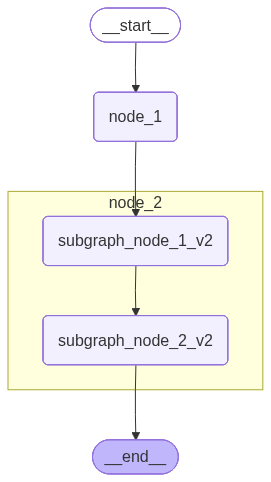

In [12]:
# 그래프 흐름: START → node_1 → node_2(래퍼) → END
# node_1: family_name을 그대로 전달해요
# node_2(래퍼): 부모 상태(family_name) → 서브그래프 입력(name) 변환 후 invoke해요
# 독립 스키마이므로 래퍼 함수가 상태 변환을 수행해요
display(Image(graph2.get_graph(xray=True).draw_mermaid_png()))

> 💡 **실무 팁**: Case 2 패턴은 기존에 만들어진 독립적인 서브그래프를 재사용할 때 특히 유용해요. 서브그래프의 내부 구현을 바꾸지 않고, 래퍼 함수의 변환 로직만 수정하면 돼요.

In [13]:
# ---------------------------------------------------
# 독립 스키마 그래프 실행 + 내부 흐름 확인
# ---------------------------------------------------
# === Case 2 실행 결과 (subgraphs=True) ===
for namespace, chunk in graph2.stream({"family_name": "Lee", "full_name": ""}, subgraphs=True):
    if namespace:
        print(f"  [서브그래프] {namespace}: {chunk}")
    else:
        print(f"[부모 그래프] {chunk}")

[부모 그래프] {'node_1': {'family_name': 'Lee'}}
  [서브그래프] ('node_2:44cb7521-112a-91bf-0b91-0b4ee20df61d',): {'subgraph_node_1_v2': {'name': 'Alex Lee'}}
  [서브그래프] ('node_2:44cb7521-112a-91bf-0b91-0b4ee20df61d',): {'subgraph_node_2_v2': {'name': 'My name is Alex Lee'}}
[부모 그래프] {'node_2': {'full_name': 'My name is Alex Lee'}}


## 3. 3계층 서브그래프 구조 (grandchild → child → parent)

실제 복잡한 시스템에서는 서브그래프가 더 깊게 중첩될 수 있어요. 이번에는 **3단계 계층 구조**를 구현해볼게요.

각 계층은 완전히 독립적인 상태 키를 사용해요:

| 계층 | 상태 키 | 역할 |
|------|----------|------|
| `GrandChildState` | `my_grandchild_key` | 가장 안쪽 그래프 |
| `ChildState` | `my_child_key` | 중간 그래프, grandchild를 래퍼로 호출 |
| `ParentState` | `my_parent_key` | 최상위 그래프, child를 래퍼로 호출 |

```mermaid
flowchart LR
    subgraph PARENT["부모 그래프"]
        PA["parent_1"] --> CB["call_child_graph"] --> PB["parent_2"]
        subgraph CHILD["자식 그래프 (래퍼 내부)"]
            CB2["call_grandchild_graph"]
            subgraph GC["손자 그래프 (래퍼 내부)"]
                GCA["grandchild_1"]
            end
            CB2 --> GC
        end
    end

    IN["입력"] --> PA
    PB --> OUT["출력"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class IN input
    class PA,CB,PB,CB2,GCA process
    class OUT output
```

> 🔑 **핵심 개념**: 계층이 깊어져도 패턴은 동일해요. **각 계층은 자신이 직접 호출하는 바로 아래 계층만 알면 돼요**. grandchild 그래프는 parent가 존재하는지도 몰라도 돼요. 이것이 모듈화의 핵심이에요.

### 3-1. Grandchild 그래프

In [14]:
# 손자 그래프의 상태와 노드를 정의해요
from typing_extensions import TypedDict as TdDict  # 이미 TypedDict를 가져왔으므로 별칭 사용


# 손자 그래프 상태: 오직 my_grandchild_key만 사용해요
class GrandChildState(TypedDict):
    my_grandchild_key: str


def grandchild_1(state: GrandChildState) -> GrandChildState:
    """손자 그래프 노드: [GrandChild] 태그를 붙여요"""
    # 자식 또는 부모 키는 여기서 접근 불가 - 완전한 독립성!
    return {"my_grandchild_key": f'([GrandChild] {state["my_grandchild_key"]})'}


# 손자 그래프 빌더 및 컴파일
grandchild_builder = StateGraph(GrandChildState)
grandchild_builder.add_node("grandchild_1", grandchild_1)
grandchild_builder.add_edge(START, "grandchild_1")
grandchild_builder.add_edge("grandchild_1", END)
grandchild_graph = grandchild_builder.compile()

# 독립 실행 테스트
# 손자 그래프 단독 실행 테스트:
result = grandchild_graph.invoke({"my_grandchild_key": "Hi, Alex!"})
print(result)

{'my_grandchild_key': '([GrandChild] Hi, Alex!)'}


### 3-2. Child 그래프

In [15]:
# 자식 그래프 상태: my_child_key만 사용해요 (grandchild_key와 다른 키!)
class ChildState3(TypedDict):
    my_child_key: str


def call_grandchild_graph(state: ChildState3) -> ChildState3:
    """자식 그래프의 래퍼 함수 - grandchild 그래프를 호출해요

    변환 과정:
    1. my_child_key → my_grandchild_key (입력 변환)
    2. grandchild 그래프 실행
    3. my_grandchild_key → my_child_key (출력 변환)
    """
    # 1단계: 자식 상태 키 → 손자 상태 키로 변환
    grandchild_input = {"my_grandchild_key": state["my_child_key"]}

    # 2단계: 손자 그래프 실행
    grandchild_output = grandchild_graph.invoke(grandchild_input)

    # 3단계: 손자 출력을 자식 상태로 변환하면서 [Child] 태그 추가
    return {"my_child_key": f'([Child] {grandchild_output["my_grandchild_key"]})'}


# 자식 그래프 빌더 및 컴파일
child_builder = StateGraph(ChildState3)
# 컴파일된 서브그래프가 아닌 래퍼 함수를 노드로 등록해요
child_builder.add_node("child_1", call_grandchild_graph)
child_builder.add_edge(START, "child_1")
child_builder.add_edge("child_1", END)
child_graph = child_builder.compile()

# 독립 실행 테스트
# 자식 그래프 단독 실행 테스트:
result = child_graph.invoke({"my_child_key": "Hi, Alex!"})
print(result)

{'my_child_key': '([Child] ([GrandChild] Hi, Alex!))'}


### 3-3. Parent 그래프 (최상위)

In [16]:
# 부모 그래프 상태: my_parent_key만 사용해요
class ParentState3(TypedDict):
    my_parent_key: str


def parent_1(state: ParentState3) -> ParentState3:
    """부모 그래프 첫 번째 노드: [Parent1] 태그를 붙여요"""
    # 자식 또는 손자 키는 여기서 접근 불가
    return {"my_parent_key": f'([Parent1] {state["my_parent_key"]})'}


def parent_2(state: ParentState3) -> ParentState3:
    """부모 그래프 세 번째 노드: [Parent2] 태그를 붙여요"""
    return {"my_parent_key": f'([Parent2] {state["my_parent_key"]})'}


def call_child_graph(state: ParentState3) -> ParentState3:
    """부모 그래프의 래퍼 함수 - child 그래프를 호출해요

    변환 과정:
    1. my_parent_key → my_child_key (입력 변환)
    2. child 그래프 실행 (내부에서 grandchild까지 연쇄 호출)
    3. my_child_key → my_parent_key (출력 변환)
    """
    # 1단계: 부모 상태 키 → 자식 상태 키로 변환
    child_input = {"my_child_key": state["my_parent_key"]}

    # 2단계: 자식 그래프 실행 (자식 내부에서 손자까지 자동 호출)
    child_output = child_graph.invoke(child_input)

    # 3단계: 자식 출력을 부모 상태로 변환
    return {"my_parent_key": child_output["my_child_key"]}


# 부모 그래프 빌더 및 컴파일
parent_builder = StateGraph(ParentState3)
parent_builder.add_node("parent_1", parent_1)
parent_builder.add_node("child", call_child_graph)   # 래퍼 함수를 'child' 노드로 등록
parent_builder.add_node("parent_2", parent_2)
parent_builder.add_edge(START, "parent_1")
parent_builder.add_edge("parent_1", "child")
parent_builder.add_edge("child", "parent_2")
parent_builder.add_edge("parent_2", END)
parent_graph = parent_builder.compile()

# 3계층 부모 그래프 컴파일 완료!

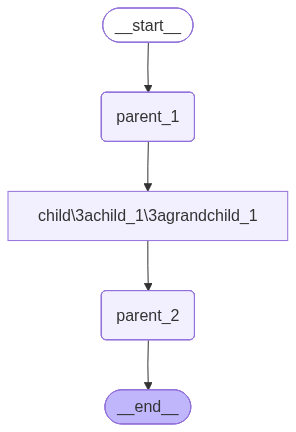

In [17]:
# 그래프 흐름: START → parent_1 → child(래퍼) → parent_2 → END
# parent_1: [Parent1] 태그를 붙여요
# child(래퍼): 내부에서 child_graph → grandchild_graph 순으로 연쇄 호출해요
# parent_2: [Parent2] 태그를 붙여요
# 각 계층은 래퍼 함수로 상태 키를 변환해요 (독립 스키마 패턴)
display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))

### 3계층 전체 실행 — subgraphs=True 로 흐름 추적

`subgraphs=True`로 실행하면 `parent → child → grandchild` 세 계층 모두의 실행 순서를 볼 수 있어요. 네임스페이스 튜플의 **길이**가 계층 깊이를 나타내요.

> 🎯 **강의 포인트**: 출력의 마지막 줄을 보면 `[Parent1]`, `[GrandChild]`, `[Child]`, `[Parent2]` 태그가 **안쪽에서 바깥으로** 중첩된 것을 확인할 수 있어요. 각 레이어의 상태 변환이 정확하게 체인으로 연결되었다는 증거예요.

In [18]:
# ---------------------------------------------------
# 3계층 그래프 전체 실행 - 각 계층의 흐름을 추적해요
# ---------------------------------------------------
# === 3계층 서브그래프 실행 결과 ===
for namespace, chunk in parent_graph.stream(
    {"my_parent_key": "Hi, Alex!"},
    subgraphs=True
):
    # 네임스페이스 길이로 계층 깊이를 표현해요
    depth = len(namespace)
    indent = "  " * depth  # 계층에 따른 들여쓰기
    layer_label = ["[부모]", "[자식]", "[손자]"][min(depth, 2)]
    print(f"{indent}{layer_label} {namespace}: {chunk}")

[부모] (): {'parent_1': {'my_parent_key': '([Parent1] Hi, Alex!)'}}
    [손자] ('child:40be403d-f639-6e6a-7ffe-b37fb3fef42e', 'child_1:dbc6a165-2008-49dc-53dc-0d3957ce21e8'): {'grandchild_1': {'my_grandchild_key': '([GrandChild] ([Parent1] Hi, Alex!))'}}
  [자식] ('child:40be403d-f639-6e6a-7ffe-b37fb3fef42e',): {'child_1': {'my_child_key': '([Child] ([GrandChild] ([Parent1] Hi, Alex!)))'}}
[부모] (): {'child': {'my_parent_key': '([Child] ([GrandChild] ([Parent1] Hi, Alex!)))'}}
[부모] (): {'parent_2': {'my_parent_key': '([Parent2] ([Child] ([GrandChild] ([Parent1] Hi, Alex!))))'}}


### 3계층 그래프 최종 결과 확인

In [19]:
# invoke()로 최종 상태만 가져올 수도 있어요
final_result = parent_graph.invoke({"my_parent_key": "Hi, Alex!"})
print("최종 결과:", final_result["my_parent_key"])

최종 결과: ([Parent2] ([Child] ([GrandChild] ([Parent1] Hi, Alex!))))


## 4. TODO 실습

아래 코드는 번역 서브그래프와 감정 분석 서브그래프를 조합하는 파이프라인이에요. 두 서브그래프는 독립적인 스키마를 가지고 있어요. 래퍼 함수를 완성해보세요!

In [ ]:
# ============================================================
# 구현 예시: translate_node 래퍼 함수 완성
# ============================================================
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model = init_chat_model("openai:gpt-4o-mini")


# -- 번역 서브그래프 (독립 스키마: text, translated) --
class TranslatorState(TypedDict):
    text: str
    translated: str


def translate_to_korean(state: TranslatorState):
    """영어 텍스트를 한국어로 번역해요."""
    response = model.invoke([
        HumanMessage(content=f"Translate to Korean in one short phrase: {state['text']}")
    ])
    return {"translated": response.content}


translator_builder = StateGraph(TranslatorState)
translator_builder.add_node("translate", translate_to_korean)
translator_builder.add_edge(START, "translate")
translator_builder.add_edge("translate", END)
translator_graph = translator_builder.compile()


# -- 부모 그래프 (독립 스키마: english_text, korean_text) --
class PipelineState(TypedDict):
    english_text: str
    korean_text: str


def translate_node(state: PipelineState):
    """부모 상태를 서브그래프 입력으로 변환하고 결과를 다시 부모 상태로 매핑해요."""
    translator_input = {"text": state["english_text"], "translated": ""}
    result = translator_graph.invoke(translator_input)
    return {"korean_text": result["translated"]}


pipeline_builder = StateGraph(PipelineState)
pipeline_builder.add_node("translate", translate_node)
pipeline_builder.add_edge(START, "translate")
pipeline_builder.add_edge("translate", END)
pipeline = pipeline_builder.compile()

result = pipeline.invoke({"english_text": "Hello World", "korean_text": ""})
print(result)


---

## 5. 가상의 실무 시나리오 — 고객 지원 티켓 라우터

마지막으로 **학생이 위에서 아래로 그대로 실행하며 따라 할 수 있는** 실무형 예제를 만들어볼게요. 이번 예제는 고객 문의를 받아서 다음 흐름으로 처리합니다.

1. 부모 그래프가 **LLM 구조화 출력**으로 문의를 읽고 `billing`, `delivery`, `account`, `general` 중 하나로 분류합니다.
2. 결제/배송/계정 문의는 각각의 **전문가 서브그래프**로 보냅니다.
3. 전문가 서브그래프는 내부 전용 `policy` 키를 사용해 답변을 만들지만, 부모 그래프에는 공유 키인 `answer`만 돌려줍니다.
4. 마지막에는 독립 스키마를 가진 **감사(audit) 서브그래프**를 래퍼 함수로 호출해서 답변 품질을 점검합니다.

```mermaid
flowchart TD
    A["사용자 문의"] --> B["부모: LLM classify_request"]
    B --> C{"category"}
    C -->|billing| D["결제 전문가 서브그래프"]
    C -->|delivery| E["배송 전문가 서브그래프"]
    C -->|account| F["계정 전문가 서브그래프"]
    C -->|general| G["부모: general_answer"]
    D --> H["부모: quality_check wrapper"]
    E --> H
    F --> H
    G --> H
    H --> I["감사 서브그래프"]
    I --> J["최종 답변"]
```

> 🎯 **강의 포인트**: 이 예제 하나 안에서 **공유 키 패턴**(전문가 서브그래프를 부모 노드로 직접 추가)과 **독립 스키마 패턴**(감사 서브그래프를 래퍼 함수로 호출)을 모두 확인할 수 있어요. `subgraphs=True`로 실행하면 어떤 서브그래프가 어떤 순서로 실행되는지도 직접 볼 수 있습니다.

### 실행 방법

아래 셀들을 순서대로 실행하세요.

실행 전 `.env`에 `OPENAI_API_KEY`가 준비되어 있어야 합니다. 이 예제는 라우팅 판단 자체를 LLM에게 맡기므로 샘플 문의 실행마다 모델 호출이 발생합니다.

1. 부모 그래프와 전문가 서브그래프가 공유할 State를 정의합니다.
2. 결제/배송/계정 전문가 서브그래프를 팩토리 함수로 만듭니다.
3. 독립 스키마를 가진 감사 서브그래프를 만듭니다.
4. 부모 그래프에서 LLM 라우팅 결과를 조건부 엣지로 연결해 전문가 서브그래프를 선택합니다.
5. 샘플 질문을 실행한 뒤, 마지막 셀에서 `my_question` 값을 바꿔 직접 테스트해 봅니다.

예시 입력:

```text
배송이 너무 늦어요.
결제했는데 영수증을 못 받았어요.
로그인이 안 되고 비밀번호 재설정 메일도 안 와요.
LangGraph 수업 자료는 어디서 볼 수 있나요?
```

In [21]:
# ------------------------------------------------------------
# 1단계: import + 부모/서브그래프 State 정의
# ------------------------------------------------------------
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph


class SupportState(TypedDict):
    """부모 그래프가 관리하는 고객 지원 State"""

    user_text: str      # 사용자가 입력한 문의
    category: str       # billing / delivery / account / general
    answer: str         # 최종 답변
    trace: list[str]    # 실행 흐름을 학생이 볼 수 있게 남기는 로그
    audit_status: str   # 감사 서브그래프의 품질 점검 결과


class SpecialistState(TypedDict):
    """전문가 서브그래프 State

    user_text/category/answer/trace는 부모와 공유하는 키입니다.
    policy는 서브그래프 내부에서만 쓰는 프라이빗 키입니다.
    """

    user_text: str
    category: str
    answer: str
    trace: list[str]
    policy: str  # 부모 SupportState에는 없는 내부 전용 키

### 2단계 — 전문가 서브그래프 만들기

세 전문가 그래프는 구조가 같습니다.

- `load_policy`: 팀별 처리 기준을 내부 전용 키 `policy`에 저장합니다.
- `compose_answer`: `policy`를 참고해 고객 답변을 작성합니다.

부모 그래프는 이 내부 `policy` 키를 몰라도 됩니다. 부모와 서브그래프가 공유하는 키(`user_text`, `category`, `answer`, `trace`)만 통로처럼 오갑니다.

In [22]:
# ------------------------------------------------------------
# 2단계: 결제/배송/계정 전문가 서브그래프 팩토리
# ------------------------------------------------------------
SPECIALIST_POLICIES = {
    "billing": {
        "label": "결제/환불",
        "policy": "환불은 주문일 기준 7일 이내 요청부터 확인하고, 결제 수단별 처리 시간을 안내합니다.",
        "next_step": "주문번호와 결제 수단을 확인한 뒤 환불 가능 여부를 답변합니다.",
    },
    "delivery": {
        "label": "배송",
        "policy": "배송 지연은 송장 상태, 출고일, 주소 변경 여부를 차례로 확인합니다.",
        "next_step": "송장번호 또는 주문번호를 받아 현재 위치와 예상 도착일을 안내합니다.",
    },
    "account": {
        "label": "계정",
        "policy": "계정/로그인 문제는 본인 확인을 먼저 진행하고 보안 설정 변경 이력을 확인합니다.",
        "next_step": "가입 이메일과 최근 로그인 가능 여부를 확인한 뒤 복구 절차를 안내합니다.",
    },
}


def build_specialist_graph(category: str):
    """같은 구조의 전문가 서브그래프를 팀별 설정만 바꿔서 생성합니다."""
    info = SPECIALIST_POLICIES[category]

    def load_policy(state: SpecialistState):
        """팀별 정책을 내부 전용 policy 키에 저장합니다."""
        return {
            "policy": info["policy"],
            "trace": state["trace"] + [f"{category}: 정책 조회"],
        }

    def compose_answer(state: SpecialistState):
        """내부 policy를 사용해 고객에게 보낼 답변을 만듭니다."""
        return {
            "answer": (
                f"[{info['label']}팀 답변] '{state['user_text']}' 문의로 확인했습니다. "
                f"안내 기준: {state['policy']} "
                f"다음 단계: {info['next_step']}"
            ),
            "trace": state["trace"] + [f"{category}: 답변 작성"],
        }

    specialist_builder = StateGraph(SpecialistState)
    specialist_builder.add_node("load_policy", load_policy)
    specialist_builder.add_node("compose_answer", compose_answer)
    specialist_builder.add_edge(START, "load_policy")
    specialist_builder.add_edge("load_policy", "compose_answer")
    specialist_builder.add_edge("compose_answer", END)
    return specialist_builder.compile()


billing_graph = build_specialist_graph("billing")
delivery_graph = build_specialist_graph("delivery")
account_graph = build_specialist_graph("account")

# 전문가 서브그래프 단독 실행 테스트
billing_graph.invoke({
    "user_text": "환불 가능한가요?",
    "category": "billing",
    "answer": "",
    "trace": [],
})

{'user_text': '환불 가능한가요?',
 'category': 'billing',
 'answer': "[결제/환불팀 답변] '환불 가능한가요?' 문의로 확인했습니다. 안내 기준: 환불은 주문일 기준 7일 이내 요청부터 확인하고, 결제 수단별 처리 시간을 안내합니다. 다음 단계: 주문번호와 결제 수단을 확인한 뒤 환불 가능 여부를 답변합니다.",
 'trace': ['billing: 정책 조회', 'billing: 답변 작성'],
 'policy': '환불은 주문일 기준 7일 이내 요청부터 확인하고, 결제 수단별 처리 시간을 안내합니다.'}

### 3단계 — 독립 스키마 감사 서브그래프 만들기

이번에는 부모 그래프와 키 이름이 다른 감사 서브그래프를 만듭니다.

- 부모 키: `answer`, `audit_status`, `trace`
- 감사 서브그래프 키: `answer_text`, `status`, `memo`

키가 다르기 때문에 이 그래프는 부모에 직접 추가하지 않고, 나중에 `quality_check` 래퍼 함수 안에서 `audit_graph.invoke(...)`로 호출합니다.

In [23]:
# ------------------------------------------------------------
# 3단계: 독립 스키마를 가진 감사(audit) 서브그래프
# ------------------------------------------------------------
class AuditState(TypedDict):
    answer_text: str  # 부모의 answer와 이름이 다릅니다.
    status: str       # 부모의 audit_status와 이름이 다릅니다.
    memo: str         # 감사 결과 설명


def audit_answer(state: AuditState):
    """답변에 담당 팀과 다음 단계가 포함되어 있는지 점검합니다."""
    has_next_step = "다음 단계" in state["answer_text"]
    has_team = "팀 답변" in state["answer_text"] or "일반 답변" in state["answer_text"]
    passed = bool(state["answer_text"].strip()) and has_next_step and has_team

    status_by_result = {
        True: "passed",
        False: "needs_revision",
    }
    memo_by_result = {
        True: "답변에 담당 팀과 다음 단계가 포함되어 있습니다.",
        False: "담당 팀 또는 다음 단계가 빠져 있습니다.",
    }

    return {
        "status": status_by_result[passed],
        "memo": memo_by_result[passed],
    }


audit_builder = StateGraph(AuditState)
audit_builder.add_node("audit_answer", audit_answer)
audit_builder.add_edge(START, "audit_answer")
audit_builder.add_edge("audit_answer", END)
audit_graph = audit_builder.compile()

# 감사 서브그래프 단독 실행 테스트
audit_graph.invoke({
    "answer_text": "[배송팀 답변] 다음 단계: 송장번호를 확인합니다.",
    "status": "",
    "memo": "",
})

{'answer_text': '[배송팀 답변] 다음 단계: 송장번호를 확인합니다.',
 'status': 'passed',
 'memo': '답변에 담당 팀과 다음 단계가 포함되어 있습니다.'}

### 4단계 — 부모 그래프 조립하기

부모 그래프의 역할은 오케스트레이션입니다.

1. `classify_request`가 **LLM 구조화 출력**으로 문의의 담당 팀, 근거, 신뢰도를 반환합니다.
2. `route_to_team` 조건부 엣지가 LLM이 고른 카테고리에 맞는 전문가 서브그래프로 보냅니다.
3. 전문가 서브그래프 또는 일반 답변 노드가 답변을 작성합니다.
4. `quality_check` 래퍼 함수가 독립 스키마 감사 서브그래프를 호출합니다.

> 💡 **실무 팁**: 라우팅은 단순 키워드보다 LLM 구조화 출력이 더 자연스럽습니다. 예를 들어 “카드에서 두 번 빠져나갔어요”처럼 `결제`라는 단어가 없어도 LLM은 결제/청구 문제로 분류할 수 있습니다.


In [24]:
# ------------------------------------------------------------
# 4단계: 부모 그래프의 LLM 라우터 노드와 라우팅 함수 정의
# ------------------------------------------------------------
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model


class SupportRoute(BaseModel):
    """LLM이 반환할 고객 문의 라우팅 결과"""

    category: Literal["billing", "delivery", "account", "general"] = Field(
        description=(
            "문의 담당 팀. billing=결제/환불/청구, delivery=배송/출고/주소, "
            "account=계정/로그인/보안, general=그 외 일반 문의"
        )
    )
    reason: str = Field(description="해당 카테고리로 분류한 짧은 근거")
    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="분류 신뢰도. 0.0은 낮음, 1.0은 매우 높음",
    )


support_router_model = init_chat_model("openai:gpt-4o-mini", temperature=0)
support_router = support_router_model.with_structured_output(SupportRoute)


ROUTER_SYSTEM_PROMPT = """당신은 고객 지원 티켓 라우터입니다.
사용자 문의를 반드시 다음 네 카테고리 중 하나로 분류하세요.

- billing: 결제, 환불, 청구, 영수증, 카드 승인, 중복 결제, 요금 문제
- delivery: 배송, 택배, 출고, 송장, 주소 변경, 도착 예정일, 배송 지연
- account: 계정, 로그인, 비밀번호, 인증, 탈퇴, 개인정보/보안 설정
- general: 위 세 팀으로 보내기 애매한 일반 제품/수업/사용법 문의

키워드가 정확히 없어도 의미를 보고 판단하세요.
예: "카드에서 두 번 빠져나갔어요"는 billing, "물건이 아직 안 왔어요"는 delivery입니다.
"""


def classify_request(state: SupportState):
    """LLM 구조화 출력으로 문의 담당 팀을 분류합니다."""
    route = support_router.invoke([
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {"role": "user", "content": state["user_text"]},
    ])

    return {
        "category": route.category,
        "trace": state["trace"] + [
            f"parent: LLM 라우팅 → {route.category} "
            f"(confidence={route.confidence:.2f}, reason={route.reason})"
        ],
    }


def route_to_team(state: SupportState) -> Literal["billing", "delivery", "account", "general"]:
    """분류 결과를 조건부 엣지의 라우팅 키로 반환합니다."""
    return state["category"]


def answer_general(state: SupportState):
    """전문가 서브그래프가 필요 없는 일반 문의 답변입니다."""
    return {
        "answer": (
            f"[일반 답변] '{state['user_text']}' 문의는 일반 상담으로 처리합니다. "
            "다음 단계: 더 자세한 상황을 알려주시면 담당 팀으로 다시 분류하겠습니다."
        ),
        "trace": state["trace"] + ["parent: 일반 답변 작성"],
    }


def quality_check(state: SupportState):
    """독립 스키마 감사 서브그래프를 호출하는 래퍼 함수입니다."""
    # 부모 State -> 감사 서브그래프 State로 입력 변환
    audit_input = {
        "answer_text": state["answer"],
        "status": "",
        "memo": "",
    }

    # 감사 서브그래프 실행
    audit_output = audit_graph.invoke(audit_input)

    # 감사 서브그래프 State -> 부모 State로 출력 변환
    return {
        "answer": state["answer"],
        "audit_status": audit_output["status"],
        "trace": state["trace"] + [f"audit: {audit_output['memo']}"],
    }


In [25]:
# ------------------------------------------------------------
# 5단계: 부모 그래프 조립 + 컴파일
# ------------------------------------------------------------
support_builder = StateGraph(SupportState)

support_builder.add_node("classify_request", classify_request)

# 공유 키 패턴: 컴파일된 전문가 서브그래프를 부모 노드로 직접 추가합니다.
support_builder.add_node("billing_specialist", billing_graph)
support_builder.add_node("delivery_specialist", delivery_graph)
support_builder.add_node("account_specialist", account_graph)

# 일반 문의와 감사 래퍼 노드는 부모 그래프의 일반 함수 노드입니다.
support_builder.add_node("general_answer", answer_general)
support_builder.add_node("quality_check", quality_check)

support_builder.add_edge(START, "classify_request")
support_builder.add_conditional_edges(
    "classify_request",
    route_to_team,
    {
        "billing": "billing_specialist",
        "delivery": "delivery_specialist",
        "account": "account_specialist",
        "general": "general_answer",
    },
)

for node_name in ["billing_specialist", "delivery_specialist", "account_specialist", "general_answer"]:
    support_builder.add_edge(node_name, "quality_check")

support_builder.add_edge("quality_check", END)
support_graph = support_builder.compile()

# 고객 지원 라우터 그래프 컴파일 완료!

### 5단계 — 그래프 구조 확인하기

`xray=True`로 보면 부모 그래프 안에 들어간 전문가 서브그래프의 내부 노드까지 펼쳐서 볼 수 있습니다.

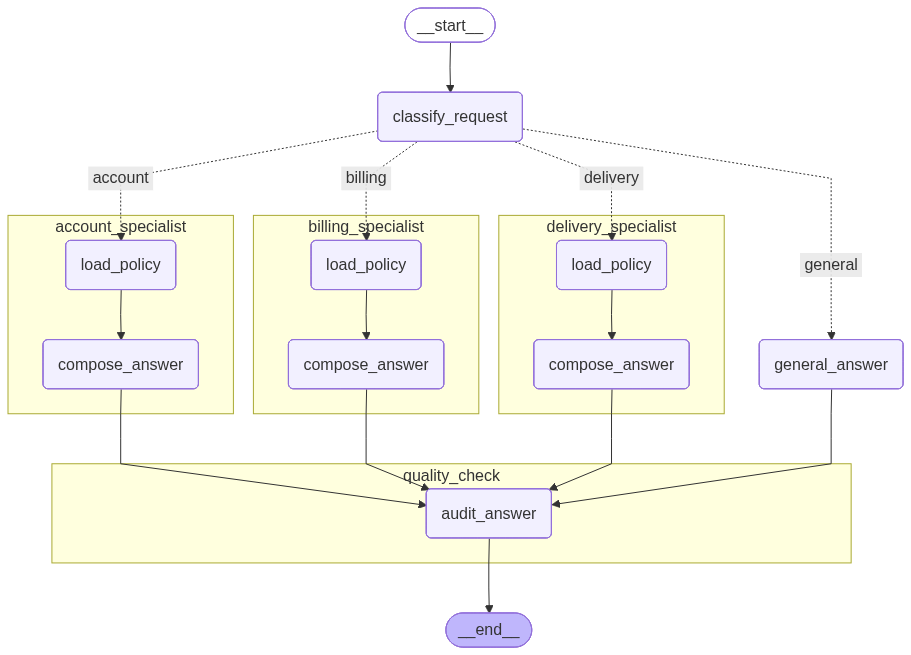

In [26]:
# 그래프 흐름: LLM classify_request → 전문가 서브그래프/일반 답변 → quality_check → END
# xray=True: 부모 그래프에 직접 추가된 전문가 서브그래프 내부를 펼쳐서 보여줍니다.
from IPython.display import Image, display

display(Image(support_graph.get_graph(xray=True).draw_mermaid_png()))

### 6단계 — 샘플 문의로 실행 흐름 추적하기

`subgraphs=True`를 켜고 스트리밍하면 부모 그래프 이벤트와 서브그래프 내부 이벤트를 함께 볼 수 있습니다. 네임스페이스가 비어 있으면 부모 그래프, 값이 있으면 특정 서브그래프 내부 이벤트입니다.

In [ ]:
# ------------------------------------------------------------
# 6단계: 실행 도우미 함수 + 샘플 질문 테스트
# ------------------------------------------------------------
def initial_support_state(user_text: str) -> SupportState:
    """매 문의마다 새 State를 만듭니다."""
    return {
        "user_text": user_text,
        "category": "",
        "answer": "",
        "trace": [],
        "audit_status": "",
    }


def run_support_turn(user_text: str):
    """한 건의 고객 문의를 실행하고 부모/서브그래프 흐름을 출력합니다."""
    print("=" * 80)
    print(f"사용자 문의: {user_text}")
    print("\n[실행 흐름]")

    final_state = None
    for namespace, chunk in support_graph.stream(
        initial_support_state(user_text),
        subgraphs=True,
        stream_mode="values",
    ):
        print(f"- namespace={namespace}: {chunk}")
        if not namespace:
            final_state = chunk

    print("\n[최종 결과]")
    print("분류:", final_state["category"])
    print("감사 상태:", final_state["audit_status"])
    print("답변:", final_state["answer"])
    print("Trace:", " → ".join(final_state["trace"]))
    return final_state


sample_questions = [
    "배송이 너무 늦어요.",
    "결제했는데 영수증을 못 받았어요.",
    "카드에서 같은 금액이 두 번 빠져나갔어요.",
    "어제 주문한 물건이 아직 안 왔는데 어디쯤인지 알 수 있나요?",
    "비번을 바꾸려는데 인증 메일이 안 와요.",
]

for question in sample_questions:
    run_support_turn(question)
    print()


사용자 문의: 배송이 너무 늦어요.

[실행 흐름]
- namespace=(): {'user_text': '배송이 너무 늦어요.', 'category': '', 'answer': '', 'trace': [], 'audit_status': ''}
- namespace=(): {'user_text': '배송이 너무 늦어요.', 'category': 'delivery', 'answer': '', 'trace': ['parent: LLM 라우팅 → delivery (confidence=0.90, reason=배송 지연으로 인한 문의)'], 'audit_status': ''}
- namespace=('delivery_specialist:a5a5b063-1c77-3e2c-3366-8f3a9776e6ac',): {'user_text': '배송이 너무 늦어요.', 'category': 'delivery', 'answer': '', 'trace': ['parent: LLM 라우팅 → delivery (confidence=0.90, reason=배송 지연으로 인한 문의)']}
- namespace=('delivery_specialist:a5a5b063-1c77-3e2c-3366-8f3a9776e6ac',): {'user_text': '배송이 너무 늦어요.', 'category': 'delivery', 'answer': '', 'trace': ['parent: LLM 라우팅 → delivery (confidence=0.90, reason=배송 지연으로 인한 문의)', 'delivery: 정책 조회'], 'policy': '배송 지연은 송장 상태, 출고일, 주소 변경 여부를 차례로 확인합니다.'}
- namespace=('delivery_specialist:a5a5b063-1c77-3e2c-3366-8f3a9776e6ac',): {'user_text': '배송이 너무 늦어요.', 'category': 'delivery', 'answer': "[배송팀 답변] '배송이 너무 늦어요.'

### 7단계 — 직접 문의를 바꿔 실행하기

마지막으로 `my_question` 문자열만 바꿔서 라우팅 결과가 어떻게 달라지는지 확인해 보세요. 이 셀은 별도의 옵션 분기 없이, 입력 문장 하나가 바로 LLM 라우터와 서브그래프 파이프라인을 통과하도록 구성했습니다.


In [28]:
# ------------------------------------------------------------
# 7단계: 직접 문의를 바꿔 실행하기
# ------------------------------------------------------------
# 아래 문자열만 원하는 문의로 바꿔서 다시 실행해 보세요.
my_question = "카드에서 같은 금액이 두 번 빠져나갔어요."

run_support_turn(my_question)


사용자 문의: 카드에서 같은 금액이 두 번 빠져나갔어요.

[실행 흐름]
- namespace=(): {'user_text': '카드에서 같은 금액이 두 번 빠져나갔어요.', 'category': '', 'answer': '', 'trace': [], 'audit_status': ''}
- namespace=(): {'user_text': '카드에서 같은 금액이 두 번 빠져나갔어요.', 'category': 'billing', 'answer': '', 'trace': ['parent: LLM 라우팅 → billing (confidence=0.90, reason=사용자가 카드에서 중복 결제가 발생했다고 보고하고 있습니다.)'], 'audit_status': ''}
- namespace=('billing_specialist:c5cda6ac-e154-ed13-0cdf-866311edcdbb',): {'user_text': '카드에서 같은 금액이 두 번 빠져나갔어요.', 'category': 'billing', 'answer': '', 'trace': ['parent: LLM 라우팅 → billing (confidence=0.90, reason=사용자가 카드에서 중복 결제가 발생했다고 보고하고 있습니다.)']}
- namespace=('billing_specialist:c5cda6ac-e154-ed13-0cdf-866311edcdbb',): {'user_text': '카드에서 같은 금액이 두 번 빠져나갔어요.', 'category': 'billing', 'answer': '', 'trace': ['parent: LLM 라우팅 → billing (confidence=0.90, reason=사용자가 카드에서 중복 결제가 발생했다고 보고하고 있습니다.)', 'billing: 정책 조회'], 'policy': '환불은 주문일 기준 7일 이내 요청부터 확인하고, 결제 수단별 처리 시간을 안내합니다.'}
- namespace=('billing_specialist:c5cda6ac

{'user_text': '카드에서 같은 금액이 두 번 빠져나갔어요.',
 'category': 'billing',
 'answer': "[결제/환불팀 답변] '카드에서 같은 금액이 두 번 빠져나갔어요.' 문의로 확인했습니다. 안내 기준: 환불은 주문일 기준 7일 이내 요청부터 확인하고, 결제 수단별 처리 시간을 안내합니다. 다음 단계: 주문번호와 결제 수단을 확인한 뒤 환불 가능 여부를 답변합니다.",
 'trace': ['parent: LLM 라우팅 → billing (confidence=0.90, reason=사용자가 카드에서 중복 결제가 발생했다고 보고하고 있습니다.)',
  'billing: 정책 조회',
  'billing: 답변 작성',
  'audit: 답변에 담당 팀과 다음 단계가 포함되어 있습니다.'],
 'audit_status': 'passed'}

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **공유 키 패턴 (Case 1)**: 부모와 서브그래프가 동일한 키를 공유하면 컴파일된 서브그래프를 `add_node`에 직접 전달할 수 있어요. LangGraph가 공유 키를 통해 상태를 자동으로 주고받아요.
- **독립 스키마 패턴 (Case 2)**: 스키마가 완전히 다른 경우, 래퍼(wrapper) 함수 안에서 `subgraph.invoke()`를 호출하고 상태를 수동으로 변환해요.
- **3계층 중첩 구조**: grandchild → child → parent 구조도 동일한 래퍼 패턴을 반복 적용해요. 각 계층은 바로 아래 계층만 알면 되고, 더 깊은 계층은 몰라도 돼요.
- **프라이빗 상태(Private State)**: 서브그래프 전용 키는 부모 그래프로 전파되지 않아요. 내부 처리용 임시 키를 안전하게 격리할 수 있어요.
- **subgraphs=True 스트리밍**: 중첩된 서브그래프의 모든 내부 단계를 추적할 수 있어요. 네임스페이스 튜플로 어느 계층에서 발생한 이벤트인지 구분해요.
- **실무 라우터 예제**: LLM 구조화 출력으로 여러 전문가 서브그래프를 선택하고, 독립 스키마 감사 서브그래프를 래퍼 함수로 호출해 실제 업무 흐름에 가까운 패턴을 구현했어요.


## 다음 노트북 예고

다음 `03-Branching-Parallel.ipynb`에서는 **병렬 분기와 Fan-out/Fan-in 패턴**을 배워요. `Annotated[list, operator.add]` reducer로 여러 노드의 결과를 안전하게 합치는 방법, 조건부 분기로 상황별 다른 경로를 선택하는 방법을 다뤄요. 이번에 만든 서브그래프를 병렬로 여러 개 실행하고 결과를 모으는 고급 패턴까지 이어져요.